# Graph Convolutional Networks for Regression: Mathematical Foundation and Implementation

## 1. Introduction

Graph Convolutional Networks (GCNs) are powerful neural networks designed to work with graph-structured data. While GCNs are commonly used for node classification tasks, they can be adapted for regression problems, particularly in molecular property prediction where we need to predict continuous values (e.g., solubility, toxicity, binding affinity) from molecular graphs.

## 2. Mathematical Foundation

### 2.1 Graph Representation

A graph $G = (V, E)$ consists of:
- **Vertices (V)**: Nodes representing atoms in molecules
- **Edges (E)**: Connections representing chemical bonds
- **Node Features (X)**: Matrix where $X_i$ represents features of node $i$
- **Adjacency Matrix (A)**: Binary matrix indicating connections

### 2.2 Graph Convolutional Layer

The core operation in a GCN layer is message passing, where each node aggregates information from its neighbors:

$$
H^{(l+1)} = σ(D^{(-1/2)} A D^{(-1/2)} H^{(l)} W^{(l)})
$$

Where:
- **$H^{(l)}$**: Node representations at layer $l$
- **$A$**: Adjacency matrix with self-loops $(A + I)$
- **$D$**: Degree matrix where $D_ii = Σ_j A_ij$
- **$W^{(l)}$**: Learnable weight matrix at layer $l$
- **$σ$**: Activation function (e.g., ReLU)

### 2.3 Normalization

The normalization term $D^{(-1/2)} A D^{(-1/2)}$ ensures that the scale of feature vectors doesn't change drastically with the node degree:

$$
A_{norm} = D^{(-1/2)} A D^{(-1/2)}
$$

This symmetric normalization helps stabilize training and improves convergence.

### 2.4 Message Passing Framework

Each GCN layer can be viewed as a message passing operation:

1. **Message**: $m_ij^{(l)} = W^{(l)} h_i^{(l)}$
2. **Aggregate**: $h_i^{(l+1)} = σ(Σ_j∈N(i) m_ij^{(l)} / √(d_i × d_j))$
3. **Update**: Update node representations

### 2.5 Graph-Level Prediction

For molecular property prediction, we need to convert node-level representations to a single graph-level prediction:

$$
h_{graph} = READOUT ({h_i^{(L)} | i ∈ V})
$$

$$
y_{pred} = MLP(h_{graph})
$$

Common readout functions include:
- **Mean**: $h_{graph} = (1/|V|) Σ_i h_i^{(L)}$
- **Max**: $h_{graph} = max_i h_i^{(L)}$
- **Sum**:$ h_{graph} = Σ_i h_i^{(L)}$
- **Attention**:$ h_{graph} = Σ_i α_i h_i^{(L)} where α_i = softmax(W_{att} h_i^{(L)})$

### 2.6 Loss Function for Regression

For regression tasks, we typically use Mean Squared Error (MSE):

$$
L = (1/N) Σ_i (y_i - ŷ_i)²
$$

Or Mean Absolute Error (MAE):

$$
L = (1/N) Σ_i |y_i - ŷ_i|
$$

## 3. Architecture Design

### 3.1 Multi-Layer GCN

A typical GCN for regression consists of:

1. **Input Layer**: Node features (atom types, charges, etc.)
2. **Hidden GCN Layers**: Multiple graph convolutional layers
3. **Readout Layer**: Graph-level pooling
4. **Output Layer**: Fully connected layers for regression

### 3.2 Skip Connections

To prevent over-smoothing in deep GCNs, we can add skip connections:

$$
H^{(l+1)} = σ(D^{-1/2} A D^{-1/2} H^{(l) }W^{(l)}) + H^{(l)}
$$

### 3.3 Dropout and Regularization

Dropout can be applied to prevent overfitting:

$$
H^{(l+1)} = σ(D^{(-1/2)} A D^{(-1/2)} Dropout(H^{(l)}) W^{(l)})
$$

## 4. Implementation

Below is a complete implementation of a GCN for molecular property regression:





Generating synthetic molecular data...


C:\Users\sashk\anaconda3\envs\mlgBookPro\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Model architecture:
GCNRegressor(
  (convs): ModuleList(
    (0): GCNConv(32, 64)
    (1-2): 2 x GCNConv(64, 64)
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
)
Number of parameters: 13441

Training model...
Epoch 000, Train Loss: 4.6267, Val Loss: 4.4361
Epoch 010, Train Loss: 1.2424, Val Loss: 0.9314
Epoch 020, Train Loss: 1.0361, Val Loss: 0.9766
Epoch 00026: reducing learning rate of group 0 to 5.0000e-04.
Epoch 030, Train Loss: 0.8839, Val Loss: 0.9502
Epoch 00037: reducing learning rate of group 0 to 2.5000e-04.
Epoch 040, Train Loss: 0.7774, Val Loss: 0.9534
Epoch 00048: reducing learning rate of group 0 to 1.2500e-04.
Epoch 050, Train Loss: 0.8782, Val Loss: 0.9757
Epoc

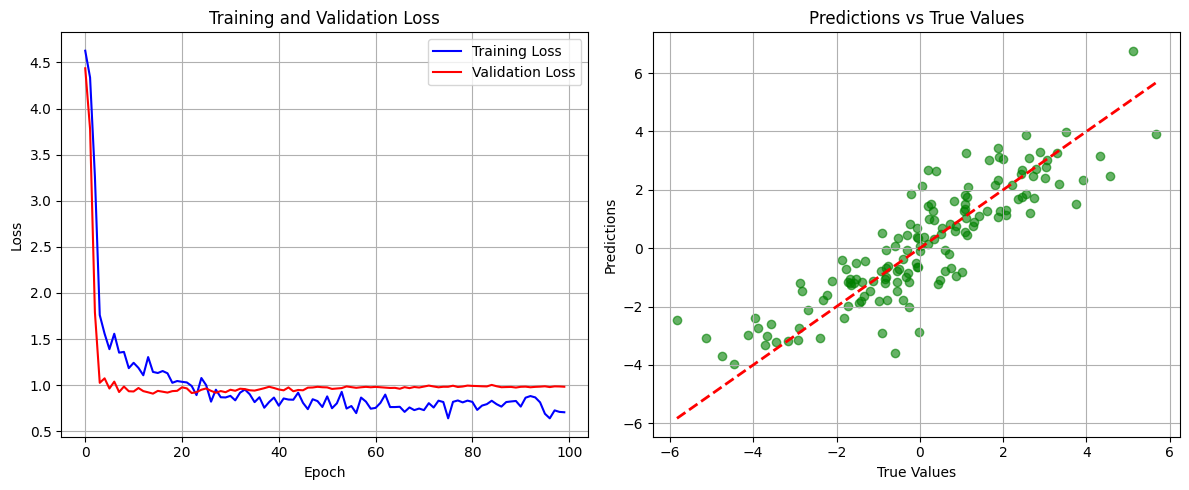

In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, DataLoader
import torch_geometric.transforms as T
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

class GCNRegressor(nn.Module):
    """
    Graph Convolutional Network for regression tasks.
    
    Args:
        input_dim: Dimension of input node features
        hidden_dim: Dimension of hidden layers
        output_dim: Dimension of output (1 for single property prediction)
        num_layers: Number of GCN layers
        dropout: Dropout probability
        pool_type: Type of graph pooling ('mean', 'max', 'add', 'attention')
    """
    
    def __init__(self, input_dim, hidden_dim=64, output_dim=1, num_layers=3, 
                 dropout=0.2, pool_type='mean'):
        super(GCNRegressor, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        self.pool_type = pool_type
        
        # GCN layers
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(input_dim, hidden_dim))
        
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Batch normalization layers
        self.batch_norms = nn.ModuleList()
        for _ in range(num_layers):
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Attention pooling (if selected)
        if pool_type == 'attention':
            self.attention = nn.Linear(hidden_dim, 1)
        
        # Output layers
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, hidden_dim // 4)
        self.fc3 = nn.Linear(hidden_dim // 4, output_dim)
        
        self.dropout_layer = nn.Dropout(dropout)
        
    def forward(self, x, edge_index, batch):
        """
        Forward pass of the GCN.
        
        Args:
            x: Node features [num_nodes, input_dim]
            edge_index: Edge indices [2, num_edges]
            batch: Batch assignment [num_nodes]
        
        Returns:
            predictions: Graph-level predictions [batch_size, output_dim]
        """
        
        # Apply GCN layers
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = self.dropout_layer(x)
        
        # Graph-level pooling
        if self.pool_type == 'mean':
            x = global_mean_pool(x, batch)
        elif self.pool_type == 'max':
            x = global_max_pool(x, batch)
        elif self.pool_type == 'add':
            x = global_add_pool(x, batch)
        elif self.pool_type == 'attention':
            # Attention-based pooling
            att_weights = torch.softmax(self.attention(x), dim=0)
            x = global_add_pool(x * att_weights, batch)
        
        # Apply output layers
        x = F.relu(self.fc1(x))
        x = self.dropout_layer(x)
        x = F.relu(self.fc2(x))
        x = self.dropout_layer(x)
        x = self.fc3(x)
        
        return x

class MolecularDataset:
    """
    Dataset class for molecular data.
    """
    
    def __init__(self, node_features, edge_indices, targets, edge_features=None):
        self.data_list = []
        
        for i in range(len(targets)):
            data = Data(
                x=torch.tensor(node_features[i], dtype=torch.float),
                edge_index=torch.tensor(edge_indices[i], dtype=torch.long).t().contiguous(),
                y=torch.tensor([targets[i]], dtype=torch.float)
            )
            
            if edge_features is not None:
                data.edge_attr = torch.tensor(edge_features[i], dtype=torch.float)
            
            self.data_list.append(data)
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        return self.data_list[idx]

def generate_synthetic_molecular_data(num_molecules=1000, num_atoms_range=(5, 20), 
                                    num_features=32):
    """
    Generate synthetic molecular data for demonstration.
    """
    node_features = []
    edge_indices = []
    targets = []
    
    for _ in range(num_molecules):
        # Random number of atoms
        num_atoms = np.random.randint(*num_atoms_range)
        
        # Random node features (representing atom properties)
        node_feat = np.random.randn(num_atoms, num_features)
        
        # Generate random molecular graph (connected)
        edges = []
        for i in range(num_atoms - 1):
            # Ensure connectivity
            edges.append([i, i + 1])
        
        # Add random additional edges
        num_additional_edges = np.random.randint(0, num_atoms // 2)
        for _ in range(num_additional_edges):
            i, j = np.random.choice(num_atoms, 2, replace=False)
            if [i, j] not in edges and [j, i] not in edges:
                edges.append([i, j])
        
        edge_index = np.array(edges)
        if len(edge_index) > 0:
            # Make undirected
            edge_index = np.vstack([edge_index, edge_index[:, [1, 0]]])
        
        # Generate synthetic target (e.g., molecular property)
        # Make it depend on molecular features for realistic behavior
        target = np.sum(node_feat) * 0.1 + np.random.randn() * 0.5
        
        node_features.append(node_feat)
        edge_indices.append(edge_index)
        targets.append(target)
    
    return node_features, edge_indices, targets

def train_model(model, train_loader, val_loader, num_epochs=100, learning_rate=0.001):
    """
    Training loop for the GCN model.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                          factor=0.5, patience=10, verbose=True)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.mse_loss(out.squeeze(), batch.y)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.batch)
                loss = F.mse_loss(out.squeeze(), batch.y)
                val_loss += loss.item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    
    return train_losses, val_losses

def evaluate_model(model, test_loader):
    """
    Evaluate the trained model.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    predictions = []
    true_values = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            predictions.extend(out.squeeze().cpu().numpy())
            true_values.extend(batch.y.cpu().numpy())
    
    predictions = np.array(predictions)
    true_values = np.array(true_values)
    
    # Calculate metrics
    mse = mean_squared_error(true_values, predictions)
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    
    print(f'Test Results:')
    print(f'MSE: {mse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R²: {r2:.4f}')
    
    return predictions, true_values, {'mse': mse, 'mae': mae, 'r2': r2}

def plot_results(predictions, true_values, train_losses, val_losses):
    """
    Plot training curves and prediction vs true values.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Training curves
    ax1.plot(train_losses, label='Training Loss', color='blue')
    ax1.plot(val_losses, label='Validation Loss', color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Predictions vs True Values
    ax2.scatter(true_values, predictions, alpha=0.6, color='green')
    ax2.plot([true_values.min(), true_values.max()], 
             [true_values.min(), true_values.max()], 'r--', lw=2)
    ax2.set_xlabel('True Values')
    ax2.set_ylabel('Predictions')
    ax2.set_title('Predictions vs True Values')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def main():
    """
    Main function to run the GCN regression experiment.
    """
    # Generate synthetic data
    print("Generating synthetic molecular data...")
    node_features, edge_indices, targets = generate_synthetic_molecular_data(
        num_molecules=1000, num_atoms_range=(5, 20), num_features=32
    )
    
    # Create dataset
    dataset = MolecularDataset(node_features, edge_indices, targets)
    
    # Split data
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    
    train_dataset = dataset[:train_size]
    val_dataset = dataset[train_size:train_size + val_size]
    test_dataset = dataset[train_size + val_size:]
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Initialize model
    model = GCNRegressor(
        input_dim=32,
        hidden_dim=64,
        output_dim=1,
        num_layers=3,
        dropout=0.2,
        pool_type='mean'
    )
    
    print(f"Model architecture:")
    print(model)
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    # Train model
    print("\nTraining model...")
    train_losses, val_losses = train_model(model, train_loader, val_loader, 
                                          num_epochs=100, learning_rate=0.001)
    
    # Evaluate model
    print("\nEvaluating model...")
    predictions, true_values, metrics = evaluate_model(model, test_loader)
    
    # Plot results
    plot_results(predictions, true_values, train_losses, val_losses)
    
    return model, metrics

if __name__ == "__main__":
    model, metrics = main()


## 5. Key Considerations for Molecular Property Prediction

### 5.1 Feature Engineering

For real molecular data, consider:

- **Atom features**: Atomic number, formal charge, hybridization, aromaticity
- **Bond features**: Bond type, conjugation, ring membership
- **Molecular descriptors**: Molecular weight, LogP, TPSA

### 5.2 Data Preprocessing

- **Normalization**: Standardize node features and target values
- **Augmentation**: Random rotation, reflection for molecules
- **Imbalanced data**: Use appropriate sampling techniques

### 5.3 Model Architecture Choices

- **Depth**: 3-5 layers typically work well for molecular graphs
- **Pooling**: Attention-based pooling often performs better than simple mean/max
- **Regularization**: Dropout, L2 regularization, early stopping

### 5.4 Evaluation Metrics

Common metrics for molecular property prediction:
- **RMSE**: Root Mean Square Error
- **MAE**: Mean Absolute Error
- **R²**: Coefficient of determination
- **Pearson correlation**: Linear correlation between predictions and true values

## 6. Advanced Techniques

### 6.1 Multi-Task Learning

Predict multiple molecular properties simultaneously:

```python
class MultiTaskGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_tasks):
        super().__init__()
        self.shared_layers = GCNRegressor(input_dim, hidden_dim, hidden_dim)
        self.task_heads = nn.ModuleList([
            nn.Linear(hidden_dim, 1) for _ in range(num_tasks)
        ])
    
    def forward(self, x, edge_index, batch):
        shared_repr = self.shared_layers(x, edge_index, batch)
        return [head(shared_repr) for head in self.task_heads]
```

### 6.2 Graph Attention Networks

Use attention mechanisms to learn important molecular substructures:

```python
from torch_geometric.nn import GATConv

class GATRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads=4):
        super().__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=num_heads, dropout=0.2)
        self.conv2 = GATConv(hidden_dim * num_heads, hidden_dim, heads=1, dropout=0.2)
```

### 6.3 Molecular Fingerprints Integration

Combine GCN representations with traditional molecular fingerprints:

```python
class HybridPredictor(nn.Module):
    def __init__(self, gcn_dim, fingerprint_dim):
        super().__init__()
        self.gcn = GCNRegressor(...)
        self.fp_mlp = nn.Linear(fingerprint_dim, gcn_dim)
        self.fusion = nn.Linear(gcn_dim * 2, 1)
    
    def forward(self, x, edge_index, batch, fingerprints):
        gcn_repr = self.gcn(x, edge_index, batch)
        fp_repr = self.fp_mlp(fingerprints)
        combined = torch.cat([gcn_repr, fp_repr], dim=1)
        return self.fusion(combined)
```

## 7. Conclusion

Graph Convolutional Networks provide a powerful framework for molecular property prediction by leveraging the natural graph structure of molecules. The key advantages include:

1. **Permutation invariance**: Predictions are invariant to atom ordering
2. **Inductive learning**: Can generalize to unseen molecular structures
3. **Interpretability**: Attention mechanisms can highlight important molecular substructures
4. **Scalability**: Can handle molecules of varying sizes efficiently

The implementation provided serves as a solid foundation that can be extended with more sophisticated architectures, better feature engineering, and domain-specific optimizations for real-world molecular property prediction tasks.